In [1]:
from pydicom import dcmread
from pydicom.data import get_testdata_files
import pandas as pd
import numpy as np
import os
import torch

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import numpy as np
from pydicom import dcmread
import os
import cv2
import keras
from keras.layers import Dense, Dropout, Flatten
from keras.models import Sequential 
from keras.layers import Convolution2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D, AveragePooling2D
from keras import optimizers

In [2]:
import os
import cv2
import keras
from keras.layers import Dense, Dropout, Flatten
from keras.models import Sequential 
from keras.layers import Convolution2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D, AveragePooling2D
import matplotlib.pyplot as plt
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import concatenate
from keras import optimizers

from keras.wrappers.scikit_learn import KerasClassifier

from tensorflow.keras.applications import ResNet50
import gc
from tensorflow.keras import regularizers
from keras import callbacks
from keras import backend as K
from sklearn.model_selection import KFold
import glob
import pickle

from keras.layers import Dense, Input, Conv2D, Flatten, MaxPooling2D, Activation, Dropout, Average
from keras.models import Model
from keras.models import load_model
from tensorflow.keras.callbacks import LearningRateScheduler

In [3]:
from pydicom import dcmread
from pydicom.data import get_testdata_files
import pandas as pd
import numpy as np
import os
import torch

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import numpy as np
from pydicom import dcmread
import os
import cv2
import keras
from keras.layers import Dense, Dropout, Flatten
from keras.models import Sequential 
from keras.layers import Convolution2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D, AveragePooling2D, MaxPool2D
from keras import optimizers

In [4]:
from tensorflow.keras.layers import Dense, BatchNormalization
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import LearningRateScheduler

# load training data

In [5]:
df = pd.read_csv('train2.csv') # create df

In [6]:
x = df['ID'].values #重新設定檔名

In [7]:
L = []
for i in range(len(x)):
    if len(str(x[i])) < 7:
        t = '0'* (7- len(str(x[i])))
        file = t + str(x[i])
    else:
        file = str(x[i])
    L.append(file)

In [8]:
df['ID'] = L # reset ID to make it consistency
df

,ID,Disease
0,1067739,1
1,1038067,0
2,0422411,1
3,0091553,1
4,1047213,1
...,...,...
155,0651657,1
156,0436524,1
157,0148593,1
158,1057213,1


In [9]:
#load T1 data
T1 = [] 
for i in df['ID']:
    path = 'C:\\Users\\James\\DICOM2\\'+ i +'\\T1' #set path
    os.chdir(path) #to filepath
    x = os.listdir() 
    data = [0]*len(x) #create array to put image，每個病患都不同數量
    for j in x:
        ds = dcmread(j) #read dicom
        WC = ds.WindowCenter # WC = (最高可視 + 最低) / 2
        WW = ds.WindowWidth # WW = H-L
        H = (int(ds.WindowCenter)*2 + int(ds.WindowWidth)) / 2 
        L = H - int(ds.WindowWidth)
        arr = np.array(ds.pixel_array) #read image
        arr = arr[106:406,106:406] #crop image to 300*300 。512*512太大張了，gpu難以負荷。(OOM problem)
        # adj img_val
        arr[arr > H] = H 
        arr[arr < L] = L
        arr = 255*((arr-L)/int(WW)) # normalized to a range of [0,255]
        data[int(ds.InstanceNumber)-1] = arr #按照順序排放image
    data = np.array(data) 
    x_np = torch.from_numpy(data) # to tensor
    x_np = x_np[None, None, :] # trilinear要求五維，因此增加維度
    x_np = torch.nn.functional.interpolate(x_np, size= [22,300,300], scale_factor=None, mode='trilinear') #內插法，depth = 22 
    x_np = torch.reshape(x_np, (22,300,300))
    x_np = x_np.numpy() #back to np
    T1.append(x_np)

In [10]:
T1 = np.array(T1) # (Number,Depth,Hight,Width)
T1.shape

(160, 22, 300, 300)

In [11]:
T2 = [] 
for i in df['ID']:
    path = 'C:\\Users\\James\\DICOM2\\'+ i +'\\T2'
    os.chdir(path) #到指定資料夾
    y = os.listdir()
    data = [0]*len(y)
    for j in y:
        ds = dcmread(j)
        WC = ds.WindowCenter
        WW = ds.WindowWidth
        H = (int(ds.WindowCenter)*2 + int(ds.WindowWidth)) / 2
        L = H - int(ds.WindowWidth)
        arr = np.array(ds.pixel_array)
        arr = arr[106:406,106:406]
        arr[arr > H] = H
        arr[arr < L] = L
        arr = 255*((arr-L)/int(WW)) 
        data[int(ds.InstanceNumber)-1] = arr
    data = np.array(data)
    y_np = torch.from_numpy(data)
    y_np = y_np[None, None, :]
    y_np = torch.nn.functional.interpolate(y_np, size= [22,300,300], scale_factor=None, mode='trilinear')
    y_np = torch.reshape(y_np, (22,300,300))
    y_np = y_np.numpy()
    T2.append(y_np)

In [12]:
os.chdir('C:\\Users\\James') #到指定資料夾

In [13]:
T2 = np.array(T2) #get T2 data
T2.shape

(160, 22, 300, 300)

In [14]:
#set 3 channel (T1,T2,avg)
X_train = []
for i in range(len(T1)):
    x = T1[i]
    y = T2[i]
    z = (T1[i]+T2[i])/2
    i1 = np.expand_dims(x,axis=3)#channel1 =T1
    i2 = np.expand_dims(y,axis=3)#channel2 =T2
    i3 = np.expand_dims(z,axis=3)#channel3 =avg
    image = np.concatenate((i1,i2,i3),axis=-1) #3channel   
    image = image / 255 #歸一化
    X_train.append(image)

In [15]:
X_train = np.array(X_train)
X_train.shape  #(N,D,H,W,Channel)，3d image with 3 channel

(160, 22, 300, 300, 3)

In [16]:
y_train_all = np.array(df.Disease) #get label

In [17]:
y_train_all.shape

(160,)

In [19]:
X1_train_all = [] 
X2_train_all = []
X3_train_all = []
X4_train_all = []
X5_train_all = []
X6_train_all = []


In [20]:
for i in range(len(X_train)):
    p = X_train[i]
    X1_train_all.append(p[10])
    X2_train_all.append(p[11])
    X3_train_all.append(p[12])
    X4_train_all.append(p[13])
    X5_train_all.append(p[14])
    X6_train_all.append(p[15])


In [21]:

X1_train_all = np.array(X1_train_all)
X2_train_all = np.array(X2_train_all)
X3_train_all = np.array(X3_train_all)
X4_train_all = np.array(X4_train_all)
X5_train_all = np.array(X5_train_all)
X6_train_all = np.array(X6_train_all)


In [22]:
X1_train_all.shape #  

(160, 300, 300, 3)

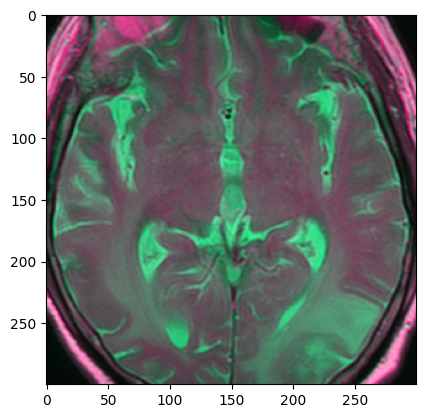

In [23]:
import matplotlib.pyplot as plt

plt.imshow(X1_train_all[0])
plt.show()

In [ ]:
# 先concatenate 6張病患資料，得到 (N,H,W, Channel * Depth) =(N, 300, 300, 18)
# 因此取 11-16 ，較容易看出腫瘤的圖片。

In [24]:
# data augmentation !! same seed same generator。 insure same patient get same augmetatopn

In [25]:
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import Sequence

#對同一組病患的data，要有相同的augment操作。
#對同個batch 做一樣的轉換

class MultipleInputGenerator(Sequence):
    """Wrapper of 2 ImageDataGenerator"""

    def __init__(self, X1, X2, X3, X4, X5, X6, y,batch_size):
        # Keras generator
        self.generator = ImageDataGenerator(rotation_range=15, 
                                            width_shift_range=0.2,
                                            height_shift_range=0.2,
                                            shear_range=0.2,
                                            zoom_range=0.2,
                                            horizontal_flip=True, 
                                            fill_mode='nearest')

        # Real time multiple input data augmentation
        self.genX1 = self.generator.flow(X1, y, batch_size=batch_size, seed=1)
        self.genX2 = self.generator.flow(X2, y, batch_size=batch_size, seed=1)
        self.genX3 = self.generator.flow(X3, y, batch_size=batch_size, seed=1)
        self.genX4 = self.generator.flow(X4, y, batch_size=batch_size, seed=1)
        self.genX5 = self.generator.flow(X5, y, batch_size=batch_size, seed=1)
        self.genX6 = self.generator.flow(X6, y, batch_size=batch_size, seed=1)

    def __len__(self):
        """It is mandatory to implement it on Keras Sequence"""
        return self.genX1.__len__()

    def __getitem__(self, index):
        """Getting items from the 2 generators and packing them"""
        X1_batch, Y_batch = self.genX1.__getitem__(index)
        X2_batch, Y_batch = self.genX2.__getitem__(index)
        X3_batch, Y_batch = self.genX3.__getitem__(index)
        X4_batch, Y_batch = self.genX4.__getitem__(index)
        X5_batch, Y_batch = self.genX5.__getitem__(index)
        X6_batch, Y_batch = self.genX6.__getitem__(index)

        X_batch = np.concatenate((X1_batch,X2_batch,X3_batch, X4_batch, X5_batch, X6_batch),axis= -1) # 輸出 concatenate model input 

        return X_batch, Y_batch

In [38]:
#valid不用做特別轉換，只是將之包起來
class validGenerator(Sequence):
    """Wrapper of 2 ImageDataGenerator"""

    def __init__(self, X1, X2, X3, X4, X5, X6, y,batch_size):
        # Keras generator
        self.generator = ImageDataGenerator()

        # Real time multiple input data augmentation
        self.genX1 = self.generator.flow(X1, y, batch_size=batch_size, seed=1)
        self.genX2 = self.generator.flow(X2, y, batch_size=batch_size, seed=1)
        self.genX3 = self.generator.flow(X3, y, batch_size=batch_size, seed=1)
        self.genX4 = self.generator.flow(X4, y, batch_size=batch_size, seed=1)
        self.genX5 = self.generator.flow(X5, y, batch_size=batch_size, seed=1)
        self.genX6 = self.generator.flow(X6, y, batch_size=batch_size, seed=1)

    def __len__(self):
        """It is mandatory to implement it on Keras Sequence"""
        return self.genX1.__len__()

    def __getitem__(self, index):
        """Getting items from the 2 generators and packing them"""
        X1_batch, Y_batch = self.genX1.__getitem__(index)
        X2_batch, Y_batch = self.genX2.__getitem__(index)
        X3_batch, Y_batch = self.genX3.__getitem__(index)
        X4_batch, Y_batch = self.genX4.__getitem__(index)
        X5_batch, Y_batch = self.genX5.__getitem__(index)
        X6_batch, Y_batch = self.genX6.__getitem__(index)

        X_batch = np.concatenate((X1_batch,X2_batch,X3_batch, X4_batch, X5_batch, X6_batch),axis= -1) # 輸出 concatenate model input 

        return X_batch, Y_batch

In [119]:
import keras
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.layers import Input, Dense, Dropout

def model():
    input1 = Input(shape=(300,300,18))
    conv1 = Conv2D(64, kernel_size=(3,3), activation='relu',padding='same')(input1)
    bn1 = BatchNormalization()(conv1)
    conv2 = Conv2D(64, kernel_size=(3,3), activation='relu',padding='same')(bn1)
    bn2 = BatchNormalization()(conv2)
    pool1 = MaxPooling2D(pool_size=(2, 2))(bn2)
    
    conv3 = Conv2D(64, kernel_size=(3,3), activation='relu',padding='same')(pool1)
    bn3 = BatchNormalization()(conv3)
    conv4 = Conv2D(64, kernel_size=(3,3), activation='relu',padding='same')(bn3)
    bn4 = BatchNormalization()(conv4)
    pool2 = MaxPooling2D(pool_size=(2, 2))(bn4)
    
    conv5 = Conv2D(128, kernel_size=(3,3), activation='relu',padding='same')(pool2)
    bn5 = BatchNormalization()(conv5)
    conv6 = Conv2D(128, kernel_size=(3,3), activation='relu',padding='same')(bn5)
    bn6 = BatchNormalization()(conv6)
    pool3 = MaxPooling2D(pool_size=(2, 2))(bn6)
    
    conv7 = Conv2D(128, kernel_size=(3,3), activation='relu',padding='same')(pool3)
    bn7 = BatchNormalization()(conv7)
    conv8 = Conv2D(128, kernel_size=(3,3), activation='relu',padding='same')(bn7)
    bn8 = BatchNormalization()(conv8)
    pool4 = MaxPooling2D(pool_size=(2, 2))(bn8)

    flat = Flatten()(pool4)
    #x = BatchNormalization()(flat)
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.L1(0.0001))(flat)
    x = Dropout(0.2)(x)
    x = Dense(64, activation='relu', kernel_regularizer=regularizers.L1(0.0001))(x)
    x = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=input1, outputs=x)
    return model

In [120]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=1e-4, decay=0.0) #優化採用adam ，起始直因batch size小。取小一點。

In [121]:
from keras.callbacks import EarlyStopping


callback = EarlyStopping(
    monitor="val_accuracy",
    min_delta=0,
    patience=15,
    verbose=0,
    mode="max")

In [122]:
# lr scheduler 每過10個epoch，降低lr
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

In [123]:
callback2 = LearningRateScheduler(scheduler)

In [124]:
model = model() #set model
PATH ='init.h5'
model.save_weights(PATH) # init model

Fold:  1


C:\Users\James\anaconda3\envs\tf_2.6_py_3.7\lib\site-packages\keras\engine\training.py:1972: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


Epoch 1/100
35/35 - 15s - loss: 7.9705 - accuracy: 0.5146 - val_loss: 6.9995 - val_accuracy: 0.5370
Epoch 2/100
35/35 - 13s - loss: 7.0880 - accuracy: 0.5728 - val_loss: 6.8737 - val_accuracy: 0.5370
Epoch 3/100
35/35 - 13s - loss: 6.7903 - accuracy: 0.6796 - val_loss: 6.6472 - val_accuracy: 0.5370
Epoch 4/100
35/35 - 13s - loss: 6.7658 - accuracy: 0.6699 - val_loss: 6.4919 - val_accuracy: 0.4630
Epoch 5/100
35/35 - 13s - loss: 6.6699 - accuracy: 0.6117 - val_loss: 6.3615 - val_accuracy: 0.5000
Epoch 6/100
35/35 - 23s - loss: 6.3232 - accuracy: 0.6990 - val_loss: 6.4603 - val_accuracy: 0.5000
Epoch 7/100
35/35 - 26s - loss: 6.1680 - accuracy: 0.6796 - val_loss: 6.1014 - val_accuracy: 0.5556
Epoch 8/100
35/35 - 24s - loss: 5.9312 - accuracy: 0.6796 - val_loss: 6.2092 - val_accuracy: 0.5370
Epoch 9/100
35/35 - 24s - loss: 5.7049 - accuracy: 0.7282 - val_loss: 5.9241 - val_accuracy: 0.6481
Epoch 10/100
35/35 - 24s - loss: 5.4916 - accuracy: 0.7961 - val_loss: 6.4252 - val_accuracy: 0.5556

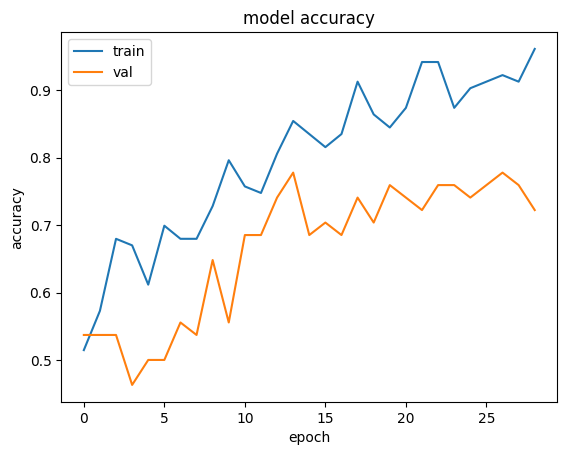

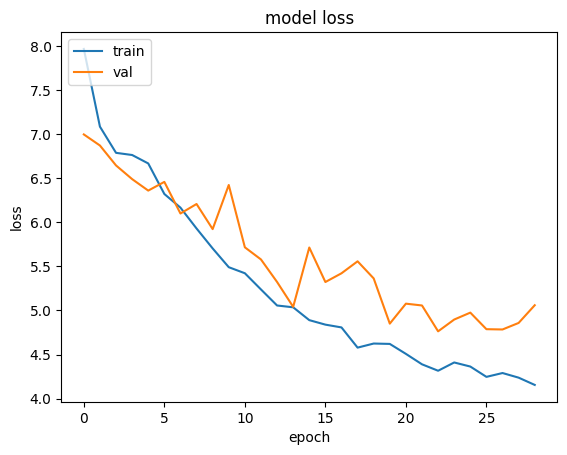

INFO:tensorflow:Assets written to: early1\assets
Fold:  2


C:\Users\James\anaconda3\envs\tf_2.6_py_3.7\lib\site-packages\keras\engine\training.py:1972: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


Epoch 1/100
35/35 - 28s - loss: 7.7063 - accuracy: 0.5192 - val_loss: 7.1917 - val_accuracy: 0.5000
Epoch 2/100
35/35 - 23s - loss: 7.5043 - accuracy: 0.5096 - val_loss: 7.2199 - val_accuracy: 0.5000
Epoch 3/100
35/35 - 23s - loss: 7.3128 - accuracy: 0.5865 - val_loss: 7.1799 - val_accuracy: 0.5000
Epoch 4/100
35/35 - 23s - loss: 7.1562 - accuracy: 0.6442 - val_loss: 7.1136 - val_accuracy: 0.5192
Epoch 5/100
35/35 - 23s - loss: 7.2335 - accuracy: 0.5769 - val_loss: 7.1081 - val_accuracy: 0.5385
Epoch 6/100
35/35 - 23s - loss: 7.1699 - accuracy: 0.5769 - val_loss: 7.1743 - val_accuracy: 0.5192
Epoch 7/100
35/35 - 23s - loss: 7.1207 - accuracy: 0.5769 - val_loss: 7.1644 - val_accuracy: 0.5577
Epoch 8/100
35/35 - 23s - loss: 7.0680 - accuracy: 0.6923 - val_loss: 7.0571 - val_accuracy: 0.5769
Epoch 9/100
35/35 - 23s - loss: 7.0438 - accuracy: 0.6442 - val_loss: 6.9379 - val_accuracy: 0.7115
Epoch 10/100
35/35 - 23s - loss: 7.0730 - accuracy: 0.6381 - val_loss: 6.9063 - val_accuracy: 0.7500

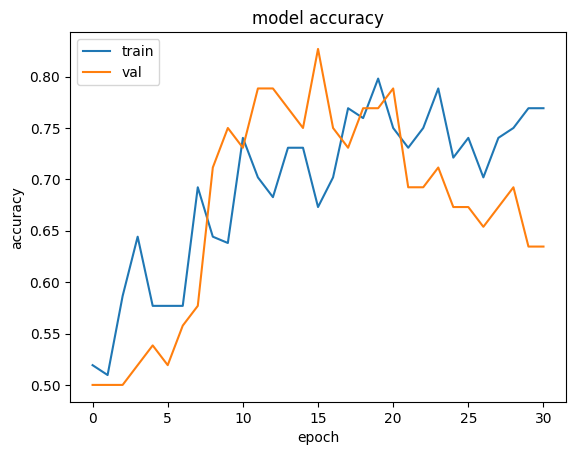

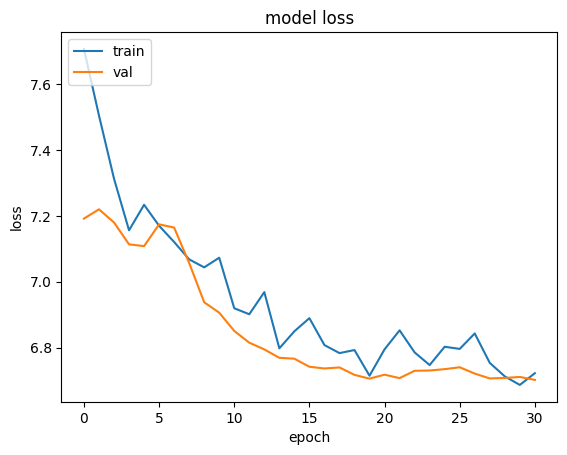

INFO:tensorflow:Assets written to: early2\assets
Fold:  3


C:\Users\James\anaconda3\envs\tf_2.6_py_3.7\lib\site-packages\keras\engine\training.py:1972: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


Epoch 1/100
35/35 - 31s - loss: 7.5177 - accuracy: 0.4808 - val_loss: 7.1835 - val_accuracy: 0.4615
Epoch 2/100
35/35 - 24s - loss: 7.3594 - accuracy: 0.5577 - val_loss: 7.1900 - val_accuracy: 0.4615
Epoch 3/100
35/35 - 23s - loss: 7.3250 - accuracy: 0.4712 - val_loss: 7.1891 - val_accuracy: 0.4615
Epoch 4/100
35/35 - 23s - loss: 7.2491 - accuracy: 0.5481 - val_loss: 7.1740 - val_accuracy: 0.3846
Epoch 5/100
35/35 - 23s - loss: 7.2089 - accuracy: 0.5769 - val_loss: 7.1628 - val_accuracy: 0.6346
Epoch 6/100
35/35 - 23s - loss: 7.1829 - accuracy: 0.6250 - val_loss: 7.1618 - val_accuracy: 0.5962
Epoch 7/100
35/35 - 23s - loss: 7.1543 - accuracy: 0.5769 - val_loss: 7.1552 - val_accuracy: 0.5962
Epoch 8/100
35/35 - 23s - loss: 7.1468 - accuracy: 0.6442 - val_loss: 7.1762 - val_accuracy: 0.5769
Epoch 9/100
35/35 - 23s - loss: 7.2384 - accuracy: 0.5288 - val_loss: 7.1908 - val_accuracy: 0.5769
Epoch 10/100
35/35 - 23s - loss: 7.1404 - accuracy: 0.5865 - val_loss: 7.1989 - val_accuracy: 0.5769

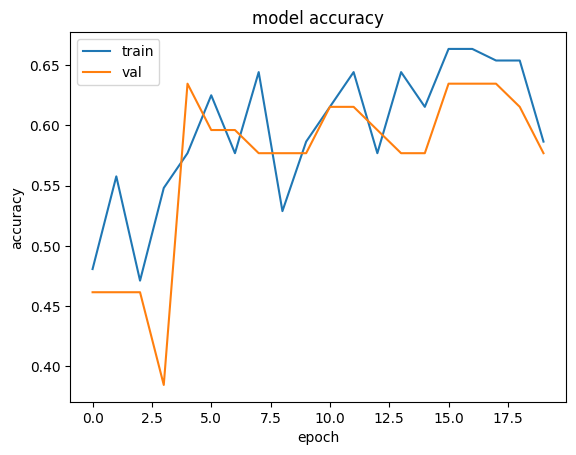

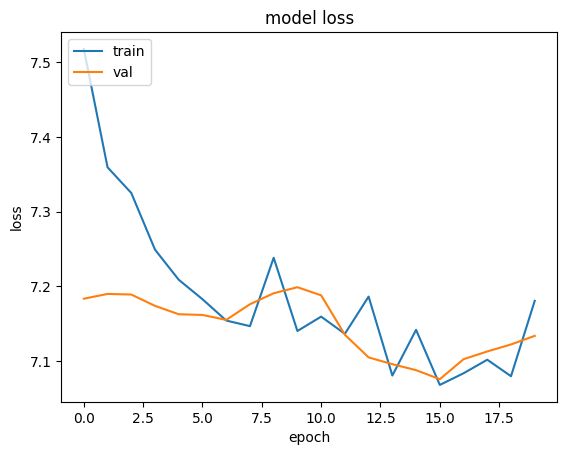

INFO:tensorflow:Assets written to: early3\assets


In [125]:
kfold = KFold(n_splits=3, shuffle=True, random_state=777) #三折 k-fold 來驗證
cvscores = []
Fold = 1
for train, val in kfold.split(X1_train_all, y_train_all):
    print ('Fold: ',Fold)
    
    #split train and val data
    X1_train = X1_train_all[train]
    X2_train = X2_train_all[train]
    X3_train = X3_train_all[train]
    X4_train = X4_train_all[train]
    X5_train = X5_train_all[train]
    X6_train = X6_train_all[train]
    
    X1_val = X1_train_all[val]
    X2_val = X2_train_all[val]
    X3_val = X3_train_all[val]
    X4_val = X4_train_all[val]
    X5_val = X5_train_all[val]
    X6_val = X6_train_all[val]
    
    y_train = y_train_all[train]
    y_val = y_train_all[val]
    
    # CREATE NEW MODEL
    model.load_weights(PATH)
    # CREATE NEW model compile
    model.compile(loss='binary_crossentropy',optimizer= optimizer, metrics=['accuracy']) 
    
    train_batch = MultipleInputGenerator(X1_train, X2_train, X3_train, X4_train, X5_train, X6_train, y_train, 3)
    val_batch = validGenerator(X1_val, X2_val, X3_val, X4_val, X5_val, X6_val, y_val, 2)
    
    epochs = 100
    history = model.fit_generator(train_batch, validation_data=val_batch, epochs=epochs, validation_steps= X1_val.shape[0] // 2, 
                        steps_per_epoch= X1_train.shape[0] // 3, callbacks=[callback,callback2], verbose=2)
    #plot history
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')
    plt.show()
    
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')
    plt.show()
    
    
    model.save('early'+ str(Fold))
    
    gc.collect() # 
    keras.backend.clear_session() #clear session
    
    Fold = Fold +1

In [ ]:
#  差不多 0.7 acc

In [126]:
#load test
os.chdir('C:\\Users\\James')
df = pd.read_csv('test2.csv')

In [127]:
x = df['ID'].values

In [128]:
L = []
for i in range(len(x)):
    if len(str(x[i])) < 7:
        t = '0'* (7- len(str(x[i])))
        file = t + str(x[i])
    else:
        file = str(x[i])
    L.append(file)

In [129]:
df['ID'] = L
df

,ID,Disease 0,Disease 1,Disease
0,1035303,NaN,NaN,NaN
1,1032110,NaN,NaN,NaN
2,0003158,NaN,NaN,NaN
3,0759590,NaN,NaN,NaN
4,0903423,NaN,NaN,NaN
5,0629424,NaN,NaN,NaN
6,0984633,NaN,NaN,NaN
7,0908999,NaN,NaN,NaN
8,0011338,NaN,NaN,NaN
9,1070273,NaN,NaN,NaN


In [130]:
T1 = [] 
for i in df['ID']:
    path = 'C:\\Users\\James\\DICOM2\\'+ i +'\\T1'
    os.chdir(path) #到指定資料夾
    x = os.listdir()
    data = [0]*len(x)
    for j in x:
        ds = dcmread(j)
        WC = ds.WindowCenter
        WW = ds.WindowWidth
        H = (int(ds.WindowCenter)*2 + int(ds.WindowWidth)) / 2
        L = H - int(ds.WindowWidth)
        arr = np.array(ds.pixel_array)
        arr = arr[106:406,106:406]
        arr[arr > H] = H
        arr[arr < L] = L
        arr = 255*((arr-L)/int(WW)) 
        data[int(ds.InstanceNumber)-1] = arr
    data = np.array(data)
    x_np = torch.from_numpy(data)
    x_np = x_np[None, None, :]
    x_np = torch.nn.functional.interpolate(x_np, size= [22,300,300], scale_factor=None, mode='trilinear')
    x_np = torch.reshape(x_np, (22,300,300))
    x_np = x_np.numpy()
    T1.append(x_np)

In [131]:
T2 = [] 
for i in df['ID']:
    path = 'C:\\Users\\James\\DICOM2\\'+ i +'\\T2'
    os.chdir(path) #到指定資料夾
    y = os.listdir()
    data = [0]*len(y)
    for j in y:
        ds = dcmread(j)
        WC = ds.WindowCenter
        WW = ds.WindowWidth
        H = (int(ds.WindowCenter)*2 + int(ds.WindowWidth)) / 2
        L = H - int(ds.WindowWidth)
        arr = np.array(ds.pixel_array)
        arr = arr[106:406,106:406]
        arr[arr > H] = H
        arr[arr < L] = L
        arr = 255*((arr-L)/int(WW)) 
        data[int(ds.InstanceNumber)-1] = arr
    data = np.array(data)
    y_np = torch.from_numpy(data)
    y_np = y_np[None, None, :]
    y_np = torch.nn.functional.interpolate(y_np, size= [22,300,300], scale_factor=None, mode='trilinear')
    y_np = torch.reshape(y_np, (22,300,300))
    y_np = y_np.numpy()
    T2.append(y_np)

In [132]:
T2 = np.array(T2)

In [133]:
X_test = []
for i in range(len(T1)):
    x = T1[i]
    y = T2[i]
    z = (T1[i]+T2[i])/2
    i1 = np.expand_dims(x,axis=3)
    i2 = np.expand_dims(y,axis=3)
    i3 = np.expand_dims(z,axis=3)
    image = np.concatenate((i1,i2,i3),axis=-1)
    image = image / 255
    X_test.append(image)

In [134]:
X_test = np.array(X_test)
X_test.shape  #(N,D,H,W,Channel)

(40, 22, 300, 300, 3)

In [135]:
# valid 跟 train 一樣分別載入三個model
X1_test = [] 
X2_test = []
X3_test = []
X4_test = [] 
X5_test = []
X6_test = []
for i in range(len(X_test)):
    p = X_test[i]
    X1_test.append(p[10])
    X2_test.append(p[11])
    X3_test.append(p[12])
    X4_test.append(p[13])
    X5_test.append(p[14])
    X6_test.append(p[15])
    
X1_test = np.array(X1_test)
X2_test = np.array(X2_test)
X3_test = np.array(X3_test)
X4_test = np.array(X4_test)
X5_test = np.array(X5_test)
X6_test = np.array(X6_test)

In [136]:
os.chdir('C:\\Users\\James')
reconstructed_model = keras.models.load_model("early1") #採用model 1來predict

In [137]:
X_test_batch = np.concatenate((X1_test,X2_test,X3_test, X4_test, X5_test, X6_test),axis= -1)

In [138]:
pred =reconstructed_model.predict(
    X_test_batch,
    batch_size= 1)

In [139]:
pred

array([[9.9209774e-01],
       [8.1756455e-01],
       [9.9992228e-01],
       [8.8797307e-01],
       [2.8761460e-02],
       [2.4563390e-01],
       [5.6763124e-03],
       [9.8291624e-01],
       [9.9999988e-01],
       [3.0160961e-01],
       [8.5198486e-01],
       [1.7144354e-02],
       [9.3474197e-01],
       [2.3297712e-01],
       [1.1507167e-02],
       [4.1228705e-04],
       [6.3197601e-01],
       [9.4469107e-04],
       [9.9999928e-01],
       [9.4162015e-04],
       [1.5753102e-04],
       [3.5425135e-05],
       [4.8045013e-03],
       [9.0191263e-01],
       [9.7498205e-04],
       [8.9144093e-01],
       [8.2553374e-03],
       [1.5157455e-01],
       [2.2763338e-04],
       [5.3308107e-05],
       [6.2782917e-04],
       [9.8636657e-01],
       [9.9999881e-01],
       [9.7192150e-01],
       [6.3247176e-06],
       [1.2236502e-02],
       [5.3486180e-01],
       [9.9999797e-01],
       [4.2255159e-04],
       [2.0704475e-04]], dtype=float32)

In [140]:
Disease_1 = pred.flatten()

In [141]:
Disease_1 = np.array(Disease_1)

In [142]:
Disease_0 = np.ones(40) - Disease_1

In [143]:
Disease_0

array([7.90226460e-03, 1.82435453e-01, 7.77244568e-05, 1.12026930e-01,
       9.71238540e-01, 7.54366100e-01, 9.94323688e-01, 1.70837641e-02,
       1.19209290e-07, 6.98390394e-01, 1.48015141e-01, 9.82855646e-01,
       6.52580261e-02, 7.67022878e-01, 9.88492833e-01, 9.99587713e-01,
       3.68023992e-01, 9.99055309e-01, 7.15255737e-07, 9.99058380e-01,
       9.99842469e-01, 9.99964575e-01, 9.95195499e-01, 9.80873704e-02,
       9.99025018e-01, 1.08559072e-01, 9.91744663e-01, 8.48425448e-01,
       9.99772367e-01, 9.99946692e-01, 9.99372171e-01, 1.36334300e-02,
       1.19209290e-06, 2.80784965e-02, 9.99993675e-01, 9.87763498e-01,
       4.65138197e-01, 2.02655792e-06, 9.99577448e-01, 9.99792955e-01])

In [144]:
Disease = []
for i in Disease_1:
    if i > 0.5:
        Disease.append(1)
    else:
        Disease.append(0)

In [145]:
Disease = np.array(Disease)

In [146]:
df.columns = ['ID', 'Disease_0', 'Disease_1', 'Disease']

In [147]:
df['Disease_0'] = Disease_0
df['Disease_1'] = Disease_1
df['Disease'] = Disease


In [148]:
df

,ID,Disease_0,Disease_1,Disease
0,1035303,7.902265e-03,0.992098,1
1,1032110,1.824355e-01,0.817565,1
2,0003158,7.772446e-05,0.999922,1
3,0759590,1.120269e-01,0.887973,1
4,0903423,9.712385e-01,0.028761,0
5,0629424,7.543661e-01,0.245634,0
6,0984633,9.943237e-01,0.005676,0
7,0908999,1.708376e-02,0.982916,1
8,0011338,1.192093e-07,1.000000,1
9,1070273,6.983904e-01,0.301610,0


In [149]:
df.to_csv("early.csv")